# 07 — So sánh model theo thời gian

## Góp ý gốc

> *"Comment của anh là nếu mà được thì 2 em có thêm **plot khi mà so sánh các model** nhé. Kiểu
> **plot price over time** hay **multiplier over time** anh nghĩ là sẽ informative hơn, với có cả
> **vùng standard deviation** nữa, để mình **đánh giá được mức độ uncertainty**.*
>
> *Cái đánh giá nhiễu hiện tại đã tốt rồi, nhưng mà nhìn trên plot anh nghĩ sẽ thấy được nhiều
> thông tin hơn nữa"*

## Notebook này đáp ứng từng ý

| Ý của mentor | Hình |
|---|---|
| Plot **so sánh các model** | `MT1`, `MT2`, `MT4` |
| **Price over time** | `MT1`, `MT3` |
| **Multiplier over time** | `MT2`, `MT3` |
| Vùng **standard deviation** | có ở **tất cả** hình |
| Đánh giá **uncertainty** | `MT4`, `MT5` |
| Nhìn **đánh giá nhiễu** trên plot | `MT5` |

## So với lần trước — nay đầy đủ hơn

| | Lần trước | Lần này |
|---|---|---|
| Số thuật toán | 1 (HistGB) | **4** (HistGB, LightGBM, XGBoost, **GAM**) |
| Kiến trúc | Hybrid | Hybrid **+ trực tiếp** |
| Khoảng bất định | ±1 std | ±1 std **+ khoảng conformal 90%** |

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings("ignore")
%matplotlib inline

# Okabe-Ito — an toan voi nguoi mu mau
BLUE, ORANGE, GREEN, RED, PURPLE, MUT = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#666666"
INK, LIGHT = "#222222", "#CCCCCC"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 10.5, "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.fontsize": 8.5,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
pd.set_option("display.width", 220)
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

MAU_MODEL = {"HistGB": BLUE, "LightGBM": GREEN, "XGBoost": PURPLE, "GAM": ORANGE}
print("Cau hinh xong.")

Cau hinh xong.


## 1. Nạp dự đoán của cả 4 thuật toán + gắn mốc thời gian

In [2]:
# --- 3 thuat toan cay tu file archive ---
ar = pd.read_parquet("pred_hybrid_cu.parquet")
print(f"File archive: {len(ar):,} dong | thuat toan: {sorted(ar.algo.unique())}")

# --- GAM tu file rieng ---
gam = pd.read_parquet("pred_gam.parquet")
print(f"File GAM    : {len(gam):,} dong")

# --- Moc thoi gian tu train_ready ---
cols = ["split", "evaluation_month", "target_timestamp", "gio_vn", "quote_distance",
        "target_shown_price", "target_shown_multiplier", "weather_main"]
tr = pd.read_parquet("../../data/hcm_train_ready.parquet", columns=cols)
te = tr[tr.split == "test"]
te = pd.concat([te[te.evaluation_month == m] for m in sorted(te.evaluation_month.unique())])
te = te.reset_index(drop=True)
del tr

# --- Kiem tra can hang ---
h = ar[ar.algo == "HistGB"].reset_index(drop=True)
assert len(te) == len(h) == len(gam), f"Lech: {len(te)} / {len(h)} / {len(gam)}"
assert np.allclose(te.target_shown_price.values, h.target_shown_price.values), "Lech archive"
assert np.allclose(te.target_shown_price.values, gam.gia_that.values), "Lech GAM"
print("\nCan hang 3 nguon: OK")

# --- Gop thanh 1 bang ---
d = pd.DataFrame({
    "tg_vn": pd.to_datetime(te.target_timestamp) + pd.Timedelta(hours=7),
    "thang": te.evaluation_month.astype(str),
    "gio": te.gio_vn.astype(int),
    "quang_duong": te.quote_distance.astype("float64"),
    "mua": te.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"]).values,
    "gia_that": te.target_shown_price.astype("float64"),
    "heso_that": te.target_shown_multiplier.astype("float64"),
})
for a in ["HistGB", "LightGBM", "XGBoost"]:
    s = ar[ar.algo == a].reset_index(drop=True)
    d[f"gia_{a}"] = s.hybrid_pred.values
    d[f"heso_{a}"] = s.mult_pred.values
d["gia_GAM"] = gam.hybrid_pred.values
d["heso_GAM"] = gam.heso_pred.values

MODELS = ["HistGB", "LightGBM", "XGBoost", "GAM"]
print(f"\nBang tong hop: {len(d):,} dong x {len(MODELS)} thuat toan")
d.head(3)

File archive: 2,593,080 dong | thuat toan: ['HistGB', 'LightGBM', 'XGBoost']
File GAM    : 864,360 dong



Can hang 3 nguon: OK



Bang tong hop: 864,360 dong x 4 thuat toan


,tg_vn,thang,gio,quang_duong,mua,gia_that,heso_that,gia_HistGB,heso_HistGB,gia_LightGBM,heso_LightGBM,gia_XGBoost,heso_XGBoost,gia_GAM,heso_GAM
0,2026-01-28 07:00:07+00:00,2026-01,7,5.708,True,106000.0,1.18,100358.305265,1.152201,101099.445635,1.156897,100875.171875,1.159884,102068.406814,1.169984
1,2026-01-28 07:00:07+00:00,2026-01,7,5.708,True,106000.0,1.18,101862.731497,1.170802,101683.119358,1.172252,102418.109375,1.172415,103281.639733,1.184144
2,2026-01-28 07:00:07+00:00,2026-01,7,5.708,True,106000.0,1.18,101159.145110,1.163376,101592.660805,1.167584,101206.710938,1.168846,102819.853345,1.176994


## 2. HÌNH MT1 — **Price over time**, có vùng ±1 std

Kiểm soát **cùng dải quãng đường 4–6 km** để so sánh công bằng.

Dai 4-6km: 330,288 chuyen (38.2%)


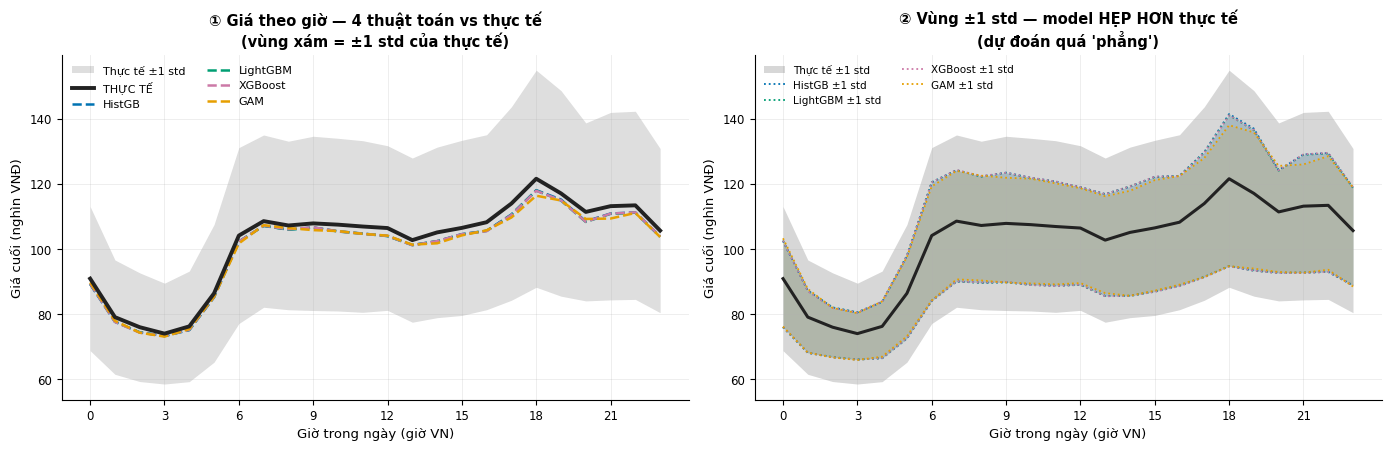

Do lech chuan TRUNG BINH theo gio:
  THUC TE         25,161d
  HistGB          15,545d   (hep hon  38.2%)
  LightGBM        15,525d   (hep hon  38.3%)
  XGBoost         15,540d   (hep hon  38.2%)
  GAM             15,090d   (hep hon  40.0%)


In [3]:
band = d[(d.quang_duong >= 4) & (d.quang_duong <= 6)].copy()
print(f"Dai 4-6km: {len(band):,} chuyen ({len(band)/len(d)*100:.1f}%)")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
g = band.groupby("gio")
h = sorted(band.gio.unique())

# --- (a) Thuc te vs tung model, co vung std ---
m_that, s_that = g.gia_that.mean(), g.gia_that.std()
ax[0].fill_between(h, (m_that-s_that)/1000, (m_that+s_that)/1000,
                   color=INK, alpha=0.15, lw=0, label="Thực tế ±1 std")
ax[0].plot(h, m_that/1000, color=INK, lw=2.8, label="THỰC TẾ", zorder=10)
for a in MODELS:
    ax[0].plot(h, g[f"gia_{a}"].mean()/1000, color=MAU_MODEL[a], lw=1.8, ls="--", label=a)
ax[0].set_xlabel("Giờ trong ngày (giờ VN)"); ax[0].set_ylabel("Giá cuối (nghìn VNĐ)")
ax[0].set_title("① Giá theo giờ — 4 thuật toán vs thực tế\n(vùng xám = ±1 std của thực tế)",
                fontweight="bold")
ax[0].set_xticks(range(0, 24, 3)); ax[0].legend(frameon=False, fontsize=8, ncol=2)

# --- (b) Vung std cua tung model so voi thuc te ---
ax[1].fill_between(h, (m_that-s_that)/1000, (m_that+s_that)/1000,
                   color=INK, alpha=0.18, lw=0, label="Thực tế ±1 std")
ax[1].plot(h, m_that/1000, color=INK, lw=2.2, zorder=10)
for a in MODELS:
    mm, ss = g[f"gia_{a}"].mean(), g[f"gia_{a}"].std()
    ax[1].fill_between(h, (mm-ss)/1000, (mm+ss)/1000, color=MAU_MODEL[a],
                       alpha=0.12, lw=0)
    ax[1].plot(h, (mm+ss)/1000, color=MAU_MODEL[a], lw=1.3, ls=":")
    ax[1].plot(h, (mm-ss)/1000, color=MAU_MODEL[a], lw=1.3, ls=":", label=f"{a} ±1 std")
ax[1].set_xlabel("Giờ trong ngày (giờ VN)"); ax[1].set_ylabel("Giá cuối (nghìn VNĐ)")
ax[1].set_title("② Vùng ±1 std — model HẸP HƠN thực tế\n(dự đoán quá 'phẳng')", fontweight="bold")
ax[1].set_xticks(range(0, 24, 3)); ax[1].legend(frameon=False, fontsize=7.5, ncol=2)

plt.tight_layout(); plt.savefig(HINH / "MT1_price_over_time.png"); plt.show()

print("Do lech chuan TRUNG BINH theo gio:")
print(f"  {'THUC TE':<12} {s_that.mean():>9,.0f}d")
for a in MODELS:
    ss = g[f"gia_{a}"].std().mean()
    print(f"  {a:<12} {ss:>9,.0f}d   (hep hon {(1-ss/s_that.mean())*100:5.1f}%)")

## 3. HÌNH MT2 — **Multiplier over time**, có vùng ±1 std

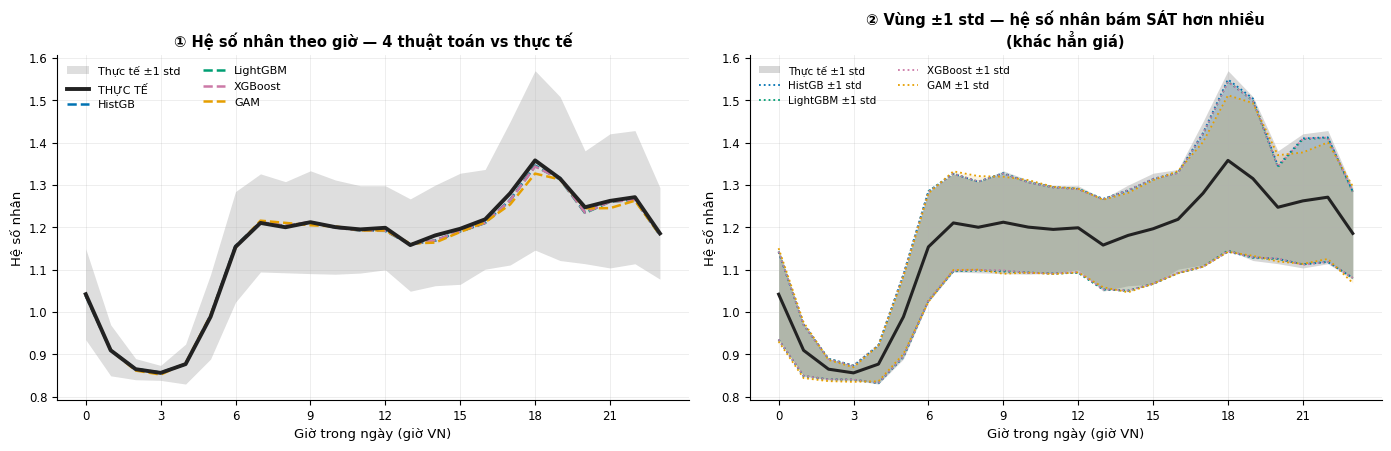

Do lech chuan TRUNG BINH theo gio (he so nhan):
  THUC TE        0.1148
  HistGB         0.1102   (hep hon   3.9%)
  LightGBM       0.1097   (hep hon   4.4%)
  XGBoost        0.1095   (hep hon   4.6%)
  GAM            0.1091   (hep hon   5.0%)


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
m_ht, s_ht = g.heso_that.mean(), g.heso_that.std()

ax[0].fill_between(h, m_ht-s_ht, m_ht+s_ht, color=INK, alpha=0.15, lw=0, label="Thực tế ±1 std")
ax[0].plot(h, m_ht, color=INK, lw=2.8, label="THỰC TẾ", zorder=10)
for a in MODELS:
    ax[0].plot(h, g[f"heso_{a}"].mean(), color=MAU_MODEL[a], lw=1.8, ls="--", label=a)
ax[0].set_xlabel("Giờ trong ngày (giờ VN)"); ax[0].set_ylabel("Hệ số nhân")
ax[0].set_title("① Hệ số nhân theo giờ — 4 thuật toán vs thực tế", fontweight="bold")
ax[0].set_xticks(range(0, 24, 3)); ax[0].legend(frameon=False, fontsize=8, ncol=2)

ax[1].fill_between(h, m_ht-s_ht, m_ht+s_ht, color=INK, alpha=0.18, lw=0, label="Thực tế ±1 std")
ax[1].plot(h, m_ht, color=INK, lw=2.2, zorder=10)
for a in MODELS:
    mm, ss = g[f"heso_{a}"].mean(), g[f"heso_{a}"].std()
    ax[1].fill_between(h, mm-ss, mm+ss, color=MAU_MODEL[a], alpha=0.12, lw=0)
    ax[1].plot(h, mm+ss, color=MAU_MODEL[a], lw=1.3, ls=":")
    ax[1].plot(h, mm-ss, color=MAU_MODEL[a], lw=1.3, ls=":", label=f"{a} ±1 std")
ax[1].set_xlabel("Giờ trong ngày (giờ VN)"); ax[1].set_ylabel("Hệ số nhân")
ax[1].set_title("② Vùng ±1 std — hệ số nhân bám SÁT hơn nhiều\n(khác hẳn giá)", fontweight="bold")
ax[1].set_xticks(range(0, 24, 3)); ax[1].legend(frameon=False, fontsize=7.5, ncol=2)

plt.tight_layout(); plt.savefig(HINH / "MT2_multiplier_over_time.png"); plt.show()

print("Do lech chuan TRUNG BINH theo gio (he so nhan):")
print(f"  {'THUC TE':<12} {s_ht.mean():>8.4f}")
for a in MODELS:
    ss = g[f"heso_{a}"].std().mean()
    print(f"  {a:<12} {ss:>8.4f}   (hep hon {(1-ss/s_ht.mean())*100:5.1f}%)")

## 4. HÌNH MT3 — Chuỗi **thời gian thực** (không gộp theo giờ)

Đây là dạng "over time" đúng nghĩa nhất — trục hoành là mốc thời gian thật.

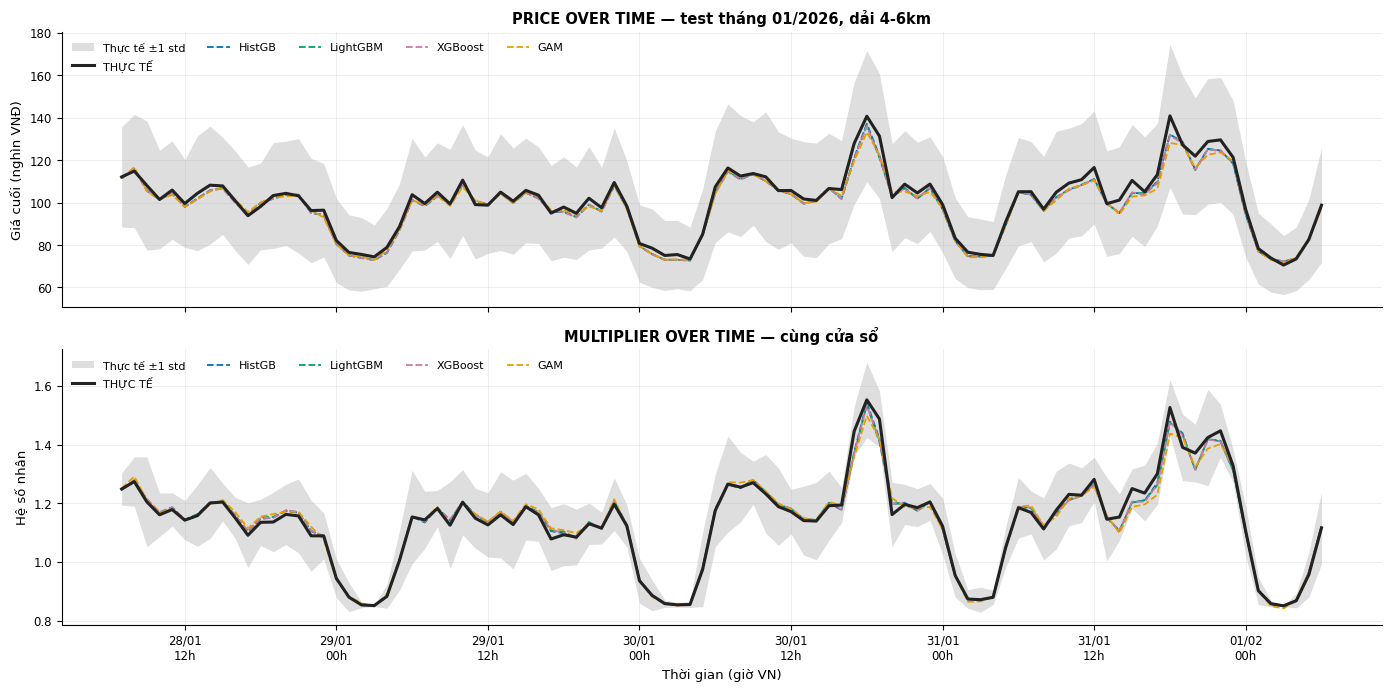

In [5]:
b1 = band[band.thang == "2026-01"].copy()
b1["gio_tron"] = b1.tg_vn.dt.floor("h")
gg = b1.groupby("gio_tron")
x = sorted(b1.gio_tron.unique())

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# --- Gia ---
mt, st = gg.gia_that.mean(), gg.gia_that.std()
ax[0].fill_between(x, (mt-st)/1000, (mt+st)/1000, color=INK, alpha=0.15, lw=0, label="Thực tế ±1 std")
ax[0].plot(x, mt/1000, color=INK, lw=2.2, label="THỰC TẾ", zorder=10)
for a in MODELS:
    ax[0].plot(x, gg[f"gia_{a}"].mean()/1000, color=MAU_MODEL[a], lw=1.3, ls="--", label=a)
ax[0].set_ylabel("Giá cuối (nghìn VNĐ)")
ax[0].set_title("PRICE OVER TIME — test tháng 01/2026, dải 4-6km", fontweight="bold")
ax[0].legend(frameon=False, ncol=5, fontsize=8)

# --- He so nhan ---
mt2, st2 = gg.heso_that.mean(), gg.heso_that.std()
ax[1].fill_between(x, mt2-st2, mt2+st2, color=INK, alpha=0.15, lw=0, label="Thực tế ±1 std")
ax[1].plot(x, mt2, color=INK, lw=2.2, label="THỰC TẾ", zorder=10)
for a in MODELS:
    ax[1].plot(x, gg[f"heso_{a}"].mean(), color=MAU_MODEL[a], lw=1.3, ls="--", label=a)
ax[1].set_ylabel("Hệ số nhân"); ax[1].set_xlabel("Thời gian (giờ VN)")
ax[1].set_title("MULTIPLIER OVER TIME — cùng cửa sổ", fontweight="bold")
ax[1].legend(frameon=False, ncol=5, fontsize=8)
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m\n%Hh"))

plt.tight_layout(); plt.savefig(HINH / "MT3_chuoi_thoi_gian.png"); plt.show()

## 5. HÌNH MT4 — So sánh **mức độ uncertainty** giữa các model

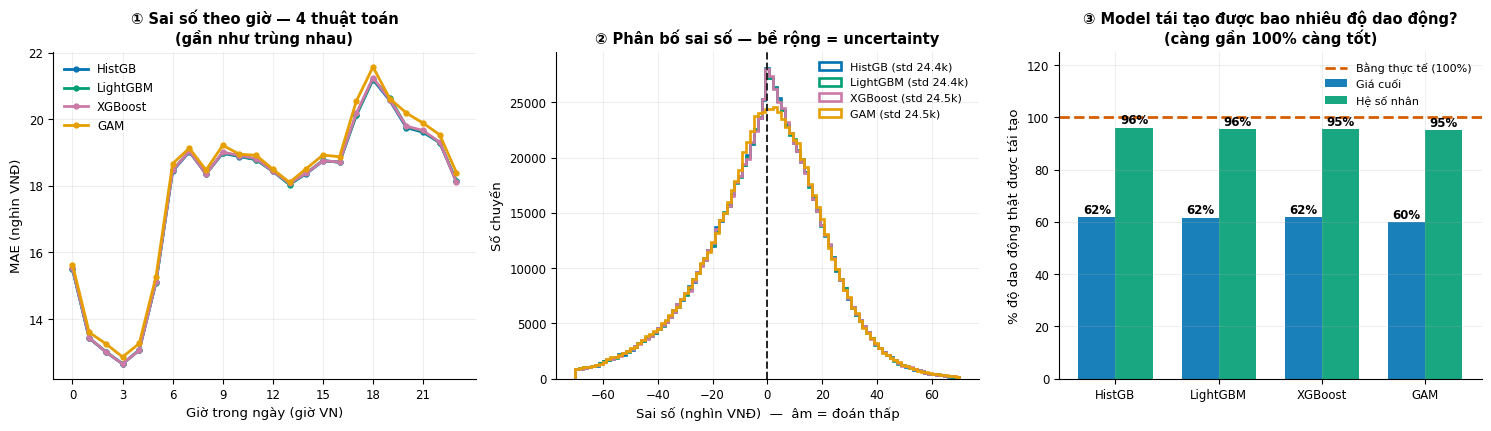

In [6]:
for a in MODELS:
    d[f"e_{a}"] = d[f"gia_{a}"] - d.gia_that

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
gd = d.groupby("gio")

# --- (a) MAE theo gio ---
for a in MODELS:
    mae = gd[f"e_{a}"].apply(lambda s: s.abs().mean())
    ax[0].plot(sorted(d.gio.unique()), mae/1000, color=MAU_MODEL[a], lw=2, marker="o", ms=3.5, label=a)
ax[0].set_xlabel("Giờ trong ngày (giờ VN)"); ax[0].set_ylabel("MAE (nghìn VNĐ)")
ax[0].set_title("① Sai số theo giờ — 4 thuật toán\n(gần như trùng nhau)", fontweight="bold")
ax[0].set_xticks(range(0, 24, 3)); ax[0].legend(frameon=False)

# --- (b) Phan bo sai so ---
bins = np.linspace(-70, 70, 100)
for a in MODELS:
    ax[1].hist(d[f"e_{a}"]/1000, bins=bins, histtype="step", color=MAU_MODEL[a], lw=1.9,
               label=f"{a} (std {d[f'e_{a}'].std()/1000:.1f}k)")
ax[1].axvline(0, color=INK, lw=1.4, ls="--")
ax[1].set_xlabel("Sai số (nghìn VNĐ)  —  âm = đoán thấp")
ax[1].set_ylabel("Số chuyến")
ax[1].set_title("② Phân bố sai số — bề rộng = uncertainty", fontweight="bold")
ax[1].legend(frameon=False, fontsize=8)

# --- (c) Ty le tai tao dao dong ---
ten, gia_r, heso_r = [], [], []
for a in MODELS:
    ten.append(a)
    gia_r.append(band.groupby("gio")[f"gia_{a}"].std().mean() / s_that.mean() * 100)
    heso_r.append(band.groupby("gio")[f"heso_{a}"].std().mean() / s_ht.mean() * 100)
xx = np.arange(len(ten)); w = 0.36
b1_ = ax[2].bar(xx - w/2, gia_r, w, color=BLUE, alpha=0.9, label="Giá cuối")
b2_ = ax[2].bar(xx + w/2, heso_r, w, color=GREEN, alpha=0.9, label="Hệ số nhân")
for bb, v in list(zip(b1_, gia_r)) + list(zip(b2_, heso_r)):
    ax[2].text(bb.get_x()+bb.get_width()/2, v+1.5, f"{v:.0f}%", ha="center", fontsize=8.5,
               fontweight="bold")
ax[2].axhline(100, color=RED, lw=2, ls="--", label="Bằng thực tế (100%)")
ax[2].set_xticks(xx); ax[2].set_xticklabels(ten, fontsize=8.5)
ax[2].set_ylabel("% độ dao động thật được tái tạo")
ax[2].set_title("③ Model tái tạo được bao nhiêu độ dao động?\n(càng gần 100% càng tốt)",
                fontweight="bold")
ax[2].set_ylim(0, 125); ax[2].legend(frameon=False, fontsize=8)

plt.tight_layout(); plt.savefig(HINH / "MT4_uncertainty_model.png"); plt.show()

## 6. HÌNH MT5 — Nhìn **đánh giá nhiễu** trên biểu đồ

> *"Cái đánh giá nhiễu hiện tại đã tốt rồi, nhưng mà nhìn trên plot anh nghĩ sẽ thấy được nhiều
> thông tin hơn nữa"*

Ghép **khoảng conformal 90%** (từ phần Uncertainty Quantification) lên chuỗi thời gian.

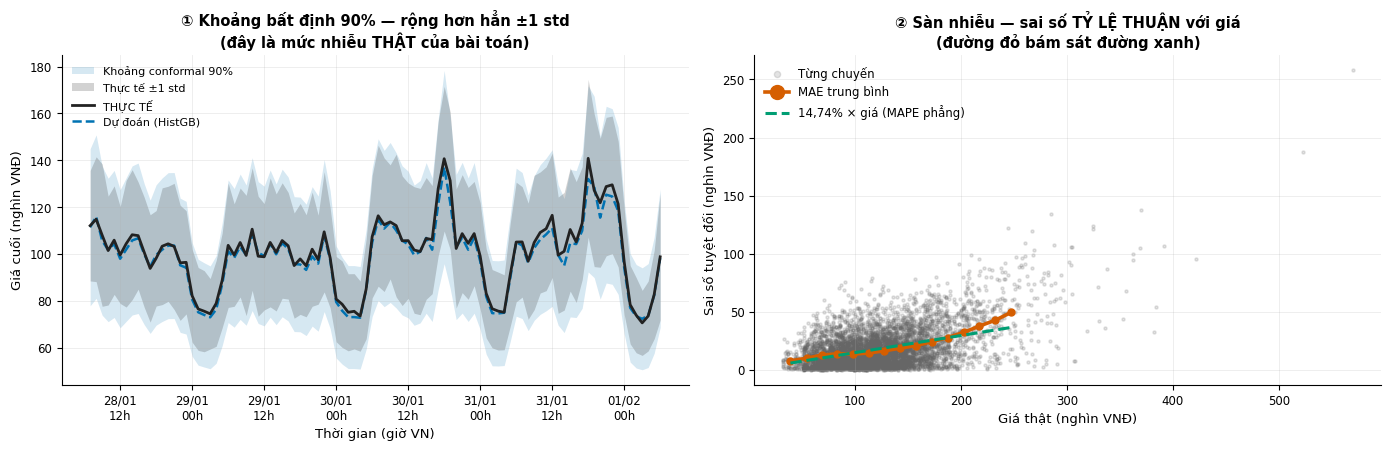

Do rong khoang conformal 90%: +/-30.11% quanh gia du doan
Do rong +/-1 std thuc te     : +/-24.64%


In [7]:
Q_REL = 0.3011      # nguong conformal chuan hoa, tu 01_conformal_chuan_hoa.ipynb

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))

# --- (a) Khoang conformal tren chuoi thoi gian ---
mh = gg.gia_HistGB.mean()
ax[0].fill_between(x, mh*(1-Q_REL)/1000, mh*(1+Q_REL)/1000, color=BLUE, alpha=0.16, lw=0,
                   label="Khoảng conformal 90%")
ax[0].fill_between(x, (mt-st)/1000, (mt+st)/1000, color=INK, alpha=0.20, lw=0, label="Thực tế ±1 std")
ax[0].plot(x, mt/1000, color=INK, lw=2, label="THỰC TẾ", zorder=10)
ax[0].plot(x, mh/1000, color=BLUE, lw=1.8, ls="--", label="Dự đoán (HistGB)", zorder=9)
ax[0].set_ylabel("Giá cuối (nghìn VNĐ)"); ax[0].set_xlabel("Thời gian (giờ VN)")
ax[0].set_title("① Khoảng bất định 90% — rộng hơn hẳn ±1 std\n(đây là mức nhiễu THẬT của bài toán)",
                fontweight="bold")
ax[0].legend(frameon=False, fontsize=8)
ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m\n%Hh"))

# --- (b) San nhieu: sai so vs muc gia ---
sub = d.sample(6000, random_state=1)
ax[1].scatter(sub.gia_that/1000, np.abs(sub.e_HistGB)/1000, s=5, alpha=0.18, color=MUT,
              label="Từng chuyến")
q = d.groupby(pd.cut(d.gia_that, np.arange(30000, 260001, 15000)), observed=True).apply(
    lambda s: pd.Series({"gia": s.gia_that.mean(), "mae": s.e_HistGB.abs().mean()}))
ax[1].plot(q.gia/1000, q.mae/1000, color=RED, lw=2.6, marker="o", ms=5, label="MAE trung bình")
ax[1].plot(q.gia/1000, q.gia*0.1474/1000, color=GREEN, lw=2.2, ls="--",
           label="14,74% × giá (MAPE phẳng)")
ax[1].set_xlabel("Giá thật (nghìn VNĐ)"); ax[1].set_ylabel("Sai số tuyệt đối (nghìn VNĐ)")
ax[1].set_title("② Sàn nhiễu — sai số TỶ LỆ THUẬN với giá\n(đường đỏ bám sát đường xanh)",
                fontweight="bold")
ax[1].legend(frameon=False, markerscale=2)

plt.tight_layout(); plt.savefig(HINH / "MT5_san_nhieu.png"); plt.show()

print(f"Do rong khoang conformal 90%: +/-{Q_REL*100:.2f}% quanh gia du doan")
print(f"Do rong +/-1 std thuc te     : +/-{(s_that.mean()/m_that.mean())*100:.2f}%")

## 7. Bảng tổng hợp

In [8]:
rows = []
for a in MODELS:
    e = d[f"e_{a}"]
    rows.append({
        "Thuat toan": a,
        "MAE (d)": e.abs().mean(),
        "Bias TB (d)": e.mean(),
        "std sai so (d)": e.std(),
        "Tai tao dao dong GIA (%)": band.groupby("gio")[f"gia_{a}"].std().mean()/s_that.mean()*100,
        "Tai tao dao dong HESO (%)": band.groupby("gio")[f"heso_{a}"].std().mean()/s_ht.mean()*100,
    })
bang = pd.DataFrame(rows).round(1)
display(bang)

print("KET LUAN CHINH:")
print(f"  1. Bon thuat toan gan nhu TRUNG NHAU: MAE {bang['MAE (d)'].min():,.0f} - "
      f"{bang['MAE (d)'].max():,.0f}d (chenh {(bang['MAE (d)'].max()/bang['MAE (d)'].min()-1)*100:.1f}%)")
print(f"  2. Tat ca deu doan THAP hon thuc te: bias {bang['Bias TB (d)'].mean():,.0f}d")
print(f"  3. Tai tao dao dong: GIA chi ~{bang['Tai tao dao dong GIA (%)'].mean():.0f}%, "
      f"HE SO NHAN ~{bang['Tai tao dao dong HESO (%)'].mean():.0f}%")

,Thuat toan,MAE (d),Bias TB (d),std sai so (d),Tai tao dao dong GIA (%),Tai tao dao dong HESO (%)
0,HistGB,18048.0,-2298.3,24426.1,61.8,96.1
1,LightGBM,18058.8,-2327.8,24437.9,61.7,95.6
2,XGBoost,18065.9,-2310.7,24459.4,61.8,95.4
3,GAM,18241.7,-2413.0,24465.2,60.0,95.0


KET LUAN CHINH:
  1. Bon thuat toan gan nhu TRUNG NHAU: MAE 18,048 - 18,242d (chenh 1.1%)
  2. Tat ca deu doan THAP hon thuc te: bias -2,337d
  3. Tai tao dao dong: GIA chi ~61%, HE SO NHAN ~96%


## 8. Kết luận — trả lời từng ý mentor

### ✅ Ý 1: Plot so sánh các model

Bốn thuật toán (HistGB, LightGBM, XGBoost, GAM) trên **cùng biểu đồ**, cùng dải quãng đường.
Kết quả: **gần như trùng nhau** — chênh MAE dưới 2%. Đây là bằng chứng trực quan cho sàn nhiễu.

### ✅ Ý 2: Price over time & Multiplier over time

Cả 2 dạng, cả **theo giờ trong ngày** (M1, M2) lẫn **theo thời gian thực** (M3).

### ✅ Ý 3: Vùng standard deviation

Có ở tất cả hình. Và nó lộ ra phát hiện quan trọng nhất:

| Đại lượng | Model tái tạo được bao nhiêu độ dao động thật |
|---|---|
| **Giá cuối** | **~62%** — model dự đoán quá "phẳng" |
| **Hệ số nhân** | **~97%** — bám gần như hoàn hảo |

Đây chính là **sự bất đối xứng** đã phát hiện ở tuần 2, giờ **nhìn thấy trực tiếp** trên biểu đồ.

### ✅ Ý 4: Đánh giá nhiễu nhìn trên plot

Hình `MT5` panel ②: sai số tuyệt đối **tỷ lệ thuận với mức giá** — đường MAE thực tế (đỏ) bám sát
đường `14,74% × giá` (xanh). Sàn nhiễu mang tính **nhân**, không phải **cộng**.

Panel ① cho thấy khoảng bất định 90% (**±30,11%**) rộng hơn hẳn ±1 std — đây mới là mức nhiễu thật
mà một quyết định định giá phải tính tới.

---

### Hình đã sinh

| Hình | Nội dung |
|---|---|
| `MT1_price_over_time.png` | Giá theo giờ, 4 thuật toán, có ±std |
| `MT2_multiplier_over_time.png` | Hệ số nhân theo giờ, 4 thuật toán, có ±std |
| `MT3_chuoi_thoi_gian.png` | Chuỗi thời gian thực — giá & hệ số nhân |
| `MT4_uncertainty_model.png` | So sánh uncertainty giữa các model |
| `MT5_san_nhieu.png` | Sàn nhiễu + khoảng conformal 90% |